DAILY CHALLENGE

In [4]:
import numpy as np
import pandas  as pd
import scipy

df = pd.read_csv('/content/sample_data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv', encoding='latin1')

df

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
0,9/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,1.0,1.0,1.0,0.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,9/7/1909,NaN,"Juvisy-sur-Orge, France",NaN,NaN,Air show,Wright Byplane,SC1,NaN,1.0,0.0,1.0,1.0,0.0,0.0,0.0,Eugene Lefebvre was the first pilot to ever be...
2,7/12/1912,6:30,"Atlantic City, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,0.0,5.0,5.0,0.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
3,8/6/1913,NaN,"Victoria, British Columbia, Canada",Private,NaN,NaN,Curtiss seaplane,NaN,NaN,1.0,0.0,1.0,1.0,0.0,1.0,0.0,The first fatal airplane accident in Canada oc...
4,9/9/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,NaN,NaN,14.0,NaN,NaN,0.0,The airship flew into a thunderstorm and encou...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4993,11/21/2022,10:15,"Medellín, Colombia",AeroPaca SAS,NaN,Medellín - Pizarro,Piper PA-31-350 Navajo Chieftain,HK-5121,31-7652004,8.0,6.0,2.0,8.0,6.0,2.0,0.0,The plane was chartered to carry a team of six...
4994,1/15/2023,10:50,"Pokhara, Nepal",Yeti Airlines,YT691,Kathmandu - Pokhara,ATR 72-500-72-212-A,9NANC,754,72.0,68.0,4.0,72.0,68.0,4.0,0.0,"Before approach, the pilot requested a change ..."
4995,9/16/2023,NaN,"Barcelos, Brazil",Manaus Aerotaxi,NaN,NaN,Embraer EMB-110P1 Bandeirante,PT-SOG,110490,14.0,12.0,2.0,14.0,12.0,2.0,0.0,The air taxi crashed in heavy rain while attem...
4996,10/29/2023,6:30,"Rio Branco, Brazil",ART Taxi Aero,NaN,Rio Branco - Envira,Cessna 208B Grand Caravan,PT-MEE,208B0344,12.0,10.0,2.0,12.0,10.0,2.0,0.0,The air taxi crashed into a heavy wooded area ...


In [5]:
print("Informations générales sur le DataFrame:")
df.info()

print("\nNombre de valeurs manquantes par colonne:")
print(df.isnull().sum())

Informations générales sur le DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   object 
 1   Time                   3486 non-null   object 
 2   Location               4994 non-null   object 
 3   Operator               4988 non-null   object 
 4   Flight #               1329 non-null   object 
 5   Route                  4221 non-null   object 
 6   AC Type                4983 non-null   object 
 7   Registration           4724 non-null   object 
 8   cn/ln                  4330 non-null   object 
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew

In [6]:
#delete duplicate value
df.drop_duplicates(inplace=True)

#dropna
df.dropna(inplace=True)
df

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary
217,1/19/1930,18:23,"Oceanside, California",Maddux Airlines,7,"Aqua Caliente, Mexico - Los Angeles",Ford 5-AT-C Tri Motor,NC9689,5-AT-046,16.0,14.0,2.0,16.0,14.0,2.0,0.0,"While en route to Los Angeles, the pilot, flyi..."
247,3/31/1931,10:45,"Bazaar, Kansas",Trans Continental and Western Air,599,Kansas City - Wichita - Los Angeles,Fokker F10A Trimotor,NC-999,1063,8.0,6.0,2.0,8.0,6.0,2.0,0.0,"Shortly after taking off from Kansas City, one..."
348,8/31/1934,22:45,"Amazonia, Missouri",Rapid Air Transport,6,Kansas City - Saint Joseph - Omaha,Stinson SM-6000B,NC11118,5004,5.0,4.0,1.0,5.0,4.0,1.0,0.0,The plane crashed about 11 miles from St. Jose...
370,5/6/1935,3:30,"Atlanta, Missouri",Trans Continental and Western Air,6,Los Angeles - Albuquerque - Kanasas City - Wa...,Douglas DC-2-112,NC13785,1295,14.0,12.0,2.0,5.0,3.0,2.0,0.0,The plane crashed while en route from Albuquer...
384,8/14/1935,23:45,"Near Gilmer, Texas",Delta Air Lines,4,Dallas - Atlanta,Stinson Model A,NC14599,9103,4.0,3.0,1.0,4.0,3.0,1.0,0.0,Crashed 3 miles south of Gilmer. The outboard ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988,3/21/2022,6:22,"Wuzhou, Guangxi, China",China Eastern Airlines,MU 5735,Kunming - Guangzhou,Boeing 737-89P WL,B-1791,41474/5453,132.0,123.0,9.0,132.0,123.0,9.0,0.0,"Flying at 29,098 feet, the jetliner started de..."
4990,7/16/2022,22:47,"Eleftheroupolis, Greece",Meridian,MEM3032,Nis- Amman,Antonov An-12,UR-CIC,1347701,8.0,0.0,8.0,8.0,0.0,8.0,0.0,The cargo plane carrying eight crew members an...
4991,11/6/2022,8:53,"Bukoba, Tanzania",Precision Air,PW494,Dar es-Salaam -Bukoba,ATR 42-500,5H-PWF,819,43.0,39.0,4.0,19.0,17.0,2.0,0.0,"While on final approach to Bukoba Airport, the..."
4992,11/18/2022,15:11,"Lima, Peru",LATAM,LA2213,Lima - Juliaca,Airbus 320-271N,CC-BHB,7864,108.0,102.0,6.0,0.0,0.0,0.0,0.0,The Airbus A320 collided with a fire truck whi...


In [7]:
df.describe()

,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground
count,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000,1245.000000
mean,63.800803,57.696386,6.124498,44.780723,40.194378,4.608032,5.157430
std,69.307128,66.443199,4.264158,56.481531,53.779553,3.836984,110.312925
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,13.000000,3.000000,8.000000,5.000000,2.000000,0.000000
50%,41.000000,36.000000,5.000000,24.000000,20.000000,4.000000,0.000000
75%,89.000000,81.000000,8.000000,62.000000,55.000000,6.000000,0.000000
max,644.000000,614.000000,61.000000,583.000000,560.000000,33.000000,2750.000000


In [8]:
print("\n--- Statistiques de base ---")
# Nombre total d'accidents (nombre de lignes après nettoyage des données)
# Cette ligne compte le nombre total d'enregistrements (accidents) dans le DataFrame 'df'.
total_accidents = len(df)
print(f"Nombre total d'accidents : {total_accidents}")

# Nombre total de décès
# Cette ligne calcule la somme de toutes les valeurs dans la colonne 'Fatalities', représentant le nombre total de personnes décédées.
total_fatalities = df['Fatalities'].sum()
print(f"Nombre total de décès : {total_fatalities:.0f}")

# Nombre total de personnes à bord
# Cette ligne calcule la somme de toutes les valeurs dans la colonne 'Aboard', représentant le nombre total de personnes à bord des avions impliqués.
total_aboard = df['Aboard'].sum()
print(f"Nombre total de personnes à bord : {total_aboard:.0f}")

# Taux de survie
# Cette ligne calcule le taux de survie en soustrayant le nombre total de décès du nombre total de personnes à bord, puis en divisant par le nombre total de personnes à bord.
survival_rate = (total_aboard - total_fatalities) / total_aboard
print(f"Taux de survie : {survival_rate:.2%}")


print("\n--- Analyse de la fréquence des accidents au fil du temps ---")
# Convertir la colonne 'Date' en format datetime
# Cette ligne convertit la colonne 'Date' en objets datetime, ce qui permet des opérations basées sur le temps.
df['Date'] = pd.to_datetime(df['Date'])

# Extraire l'année de la colonne 'Date'
# Cette ligne crée une nouvelle colonne 'Year' en extrayant l'année de chaque date.
df['Year'] = df['Date'].dt.year

# Compter le nombre d'accidents par année
# Cette ligne regroupe les données par année et compte le nombre d'accidents pour chaque année.
accidents_per_year = df['Year'].value_counts().sort_index()
print("Fréquence des accidents par année :\n", accidents_per_year.head())



--- Statistiques de base ---
Nombre total d'accidents : 1245
Nombre total de décès : 55752
Nombre total de personnes à bord : 79432
Taux de survie : 29.81%

--- Analyse de la fréquence des accidents au fil du temps ---
Fréquence des accidents par année :
 Year
1930    1
1931    1
1934    1
1935    3
1936    6
Name: count, dtype: int64


In [ ]:
import scipy.stats as stats

print("### Analyse de la répartition des mortalités ###")

# Calcul des statistiques clés pour la colonne 'Fatalities'
mean_fatalities = df['Fatalities'].mean()
median_fatalities = df['Fatalities'].median()
std_fatalities = df['Fatalities'].std()

print(f"Moyenne des décès: {mean_fatalities:.2f}")
print(f"Médiane des décès: {median_fatalities:.2f}")
print(f"Écart-type des décès: {std_fatalities:.2f}")

print("\n### Test d'hypothèse: Comparaison des décès par décennie ###")

# Créer une colonne 'Decade' pour regrouper les données par périodes de 10 ans
df['Decade'] = (df['Year'] // 10) * 10

# Sélectionner deux décennies pour le test d'hypothèse (par exemple, 1950s vs 2000s)
# Assurez-vous que ces décennies sont présentes dans vos données
decade_1 = 1950
decade_2 = 2000

# Filtrer les données pour les décennies sélectionnées
fatalities_decade_1 = df[df['Decade'] == decade_1]['Fatalities'].dropna()
fatalities_decade_2 = df[df['Decade'] == decade_2]['Fatalities'].dropna()

# Vérifier si les échantillons sont assez grands pour le test
if len(fatalities_decade_1) > 1 and len(fatalities_decade_2) > 1:
    # Effectuer un test t de Student indépendant (Student's t-test)
    # Nous utilisons equal_var=False car les variances ne sont probablement pas égales.
    t_stat, p_value = stats.ttest_ind(fatalities_decade_1, fatalities_decade_2, equal_var=False)

    print(f"Test d'hypothèse pour comparer les décès entre la décennie {decade_1} et la décennie {decade_2}:")
    print(f"  Statistique t: {t_stat:.3f}")
    print(f"  Valeur p: {p_value:.3f}")

    # Interprétation du résultat
    alpha = 0.05
    if p_value < alpha:
        print(f"  Avec un niveau de signification de {alpha}, nous rejetons l'hypothèse nulle. Il existe une différence significative dans le nombre moyen de décès entre la décennie {decade_1} et la décennie {decade_2}.")
    else:
        print(f"  Avec un niveau de signification de {alpha}, nous ne rejetons pas l'hypothèse nulle. Il n'y a pas de différence significative dans le nombre moyen de décès entre la décennie {decade_1} et la décennie {decade_2}.")
else:
    print(f"Pas assez de données pour effectuer un test d'hypothèse pour les décennies {decade_1} ou {decade_2}. Veuillez choisir des décennies avec plus de données.")

# Afficher la moyenne des décès pour chaque décennie pour un aperçu
print("\nMoyenne des décès par décennie:")
print(df.groupby('Decade')['Fatalities'].mean().dropna())

In [9]:
import scipy.stats as stats

fatalities_mean = df['Fatalities'].mean()
fatalities_median = df['Fatalities'].median()
fatalities_std = df['Fatalities'].std()

print(f"Mean : {fatalities_mean:.2f}")
print(f"Median : {fatalities_median:.2f}")
print(f"Std : {fatalities_std:.2f}")

Mean : 44.78
Median : 24.00
Std : 56.48


In [10]:
df['Decade'] = (df['Year'] // 10) * 10
df

,Date,Time,Location,Operator,Flight #,Route,AC Type,Registration,cn/ln,Aboard,Aboard Passangers,Aboard Crew,Fatalities,Fatalities Passangers,Fatalities Crew,Ground,Summary,Year,Decade
217,1930-01-19,18:23,"Oceanside, California",Maddux Airlines,7,"Aqua Caliente, Mexico - Los Angeles",Ford 5-AT-C Tri Motor,NC9689,5-AT-046,16.0,14.0,2.0,16.0,14.0,2.0,0.0,"While en route to Los Angeles, the pilot, flyi...",1930,1930
247,1931-03-31,10:45,"Bazaar, Kansas",Trans Continental and Western Air,599,Kansas City - Wichita - Los Angeles,Fokker F10A Trimotor,NC-999,1063,8.0,6.0,2.0,8.0,6.0,2.0,0.0,"Shortly after taking off from Kansas City, one...",1931,1930
348,1934-08-31,22:45,"Amazonia, Missouri",Rapid Air Transport,6,Kansas City - Saint Joseph - Omaha,Stinson SM-6000B,NC11118,5004,5.0,4.0,1.0,5.0,4.0,1.0,0.0,The plane crashed about 11 miles from St. Jose...,1934,1930
370,1935-05-06,3:30,"Atlanta, Missouri",Trans Continental and Western Air,6,Los Angeles - Albuquerque - Kanasas City - Wa...,Douglas DC-2-112,NC13785,1295,14.0,12.0,2.0,5.0,3.0,2.0,0.0,The plane crashed while en route from Albuquer...,1935,1930
384,1935-08-14,23:45,"Near Gilmer, Texas",Delta Air Lines,4,Dallas - Atlanta,Stinson Model A,NC14599,9103,4.0,3.0,1.0,4.0,3.0,1.0,0.0,Crashed 3 miles south of Gilmer. The outboard ...,1935,1930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4988,2022-03-21,6:22,"Wuzhou, Guangxi, China",China Eastern Airlines,MU 5735,Kunming - Guangzhou,Boeing 737-89P WL,B-1791,41474/5453,132.0,123.0,9.0,132.0,123.0,9.0,0.0,"Flying at 29,098 feet, the jetliner started de...",2022,2020
4990,2022-07-16,22:47,"Eleftheroupolis, Greece",Meridian,MEM3032,Nis- Amman,Antonov An-12,UR-CIC,1347701,8.0,0.0,8.0,8.0,0.0,8.0,0.0,The cargo plane carrying eight crew members an...,2022,2020
4991,2022-11-06,8:53,"Bukoba, Tanzania",Precision Air,PW494,Dar es-Salaam -Bukoba,ATR 42-500,5H-PWF,819,43.0,39.0,4.0,19.0,17.0,2.0,0.0,"While on final approach to Bukoba Airport, the...",2022,2020
4992,2022-11-18,15:11,"Lima, Peru",LATAM,LA2213,Lima - Juliaca,Airbus 320-271N,CC-BHB,7864,108.0,102.0,6.0,0.0,0.0,0.0,0.0,The Airbus A320 collided with a fire truck whi...,2022,2020


In [11]:
decade_1 = 1950
decade_2 = 2000

fatalities_decade_1 = df[df['Decade']==decade_1]['Fatalities'].dropna()
fatalities_decade_2 = df[df['Decade']==decade_2]['Fatalities'].dropna()

t_statistic, p_value = stats.ttest_ind(fatalities_decade_1, fatalities_decade_2)

print("T-statistic:", t_statistic)

print("P-value:", p_value)




T-statistic: -4.215956367344894
P-value: 3.311101233689972e-05


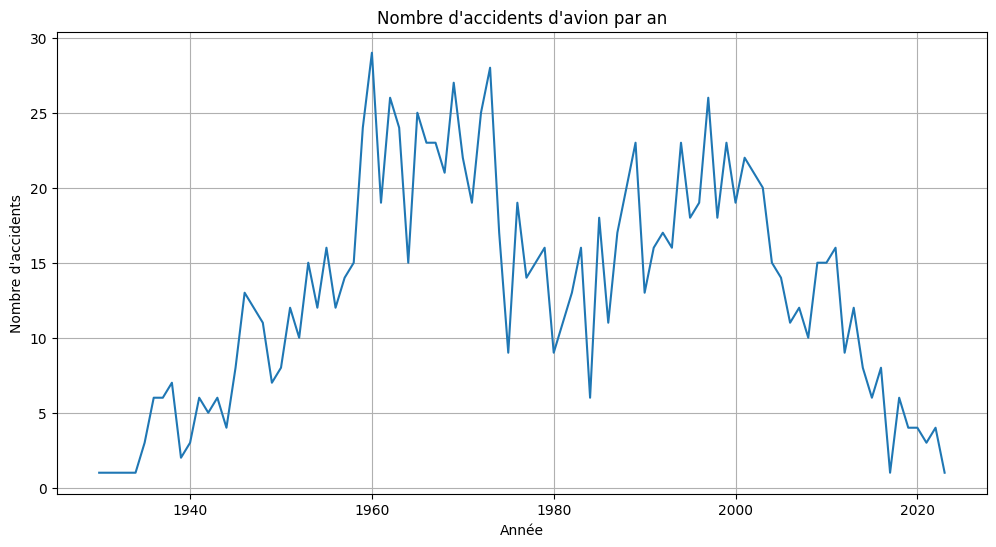

In [12]:
# Visualisation de la fréquence des accidents au fil du temps
# Importe la bibliothèque de visualisation Matplotlib.
import matplotlib.pyplot as plt

# Configure la taille de la figure pour le graphique.
plt.figure(figsize=(12, 6))
# Crée un graphique linéaire (line plot) montrant le nombre d'accidents par année.
plt.plot(accidents_per_year.index, accidents_per_year.values)
# Ajoute un titre au graphique.
plt.title("Nombre d'accidents d'avion par an")
# Ajoute une étiquette à l'axe des x.
plt.xlabel("Année")
# Ajoute une étiquette à l'axe des y.
plt.ylabel("Nombre d'accidents")
# Active la grille pour une meilleure lisibilité.
plt.grid(True)
# Affiche le graphique.
plt.show()

In [15]:
numerics_col = df.select_dtypes(include='number').columns.tolist()
print(numerics_col)

['Aboard', 'Aboard Passangers', 'Aboard Crew', 'Fatalities', 'Fatalities Passangers', 'Fatalities Crew', 'Ground', 'Year', 'Decade']


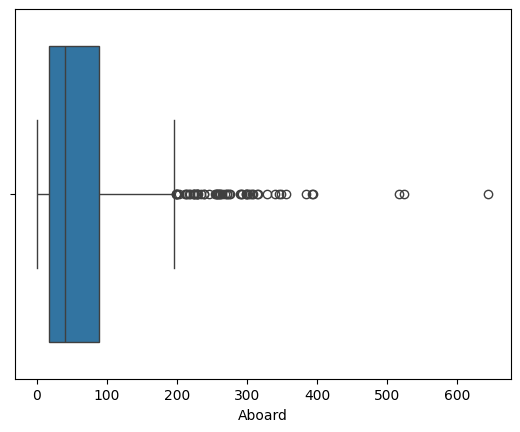

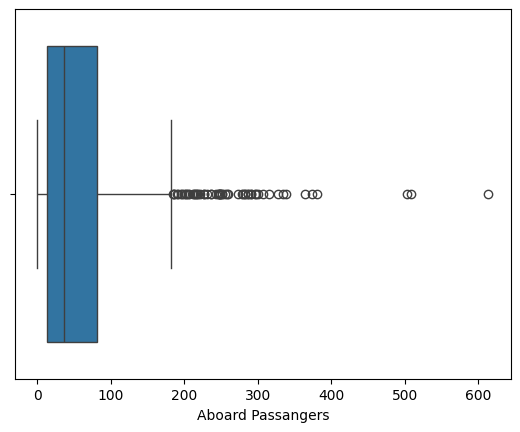

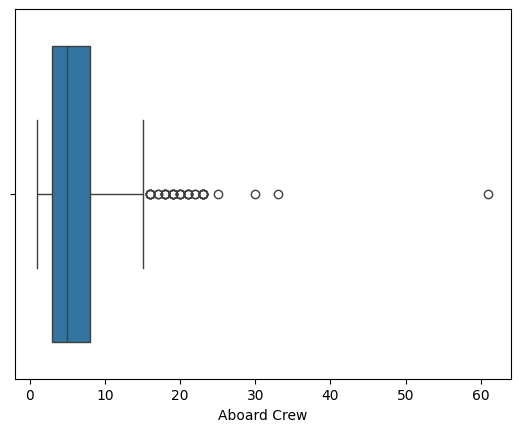

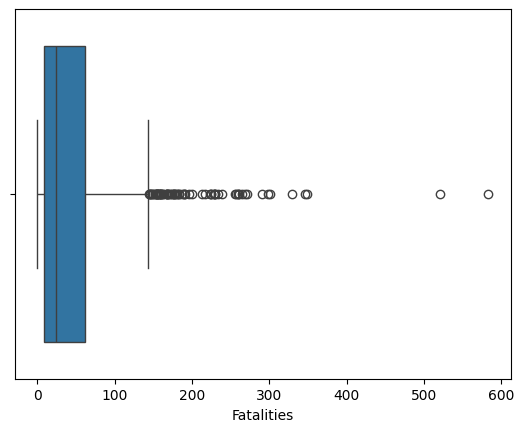

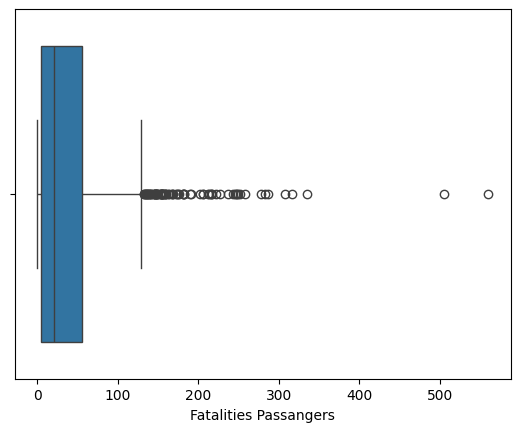

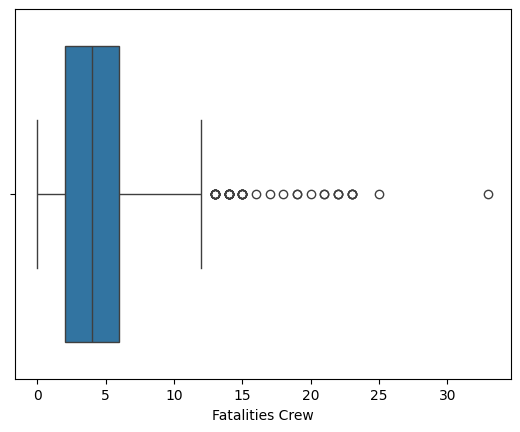

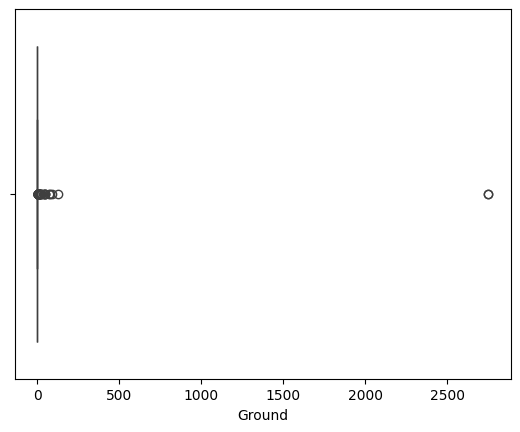

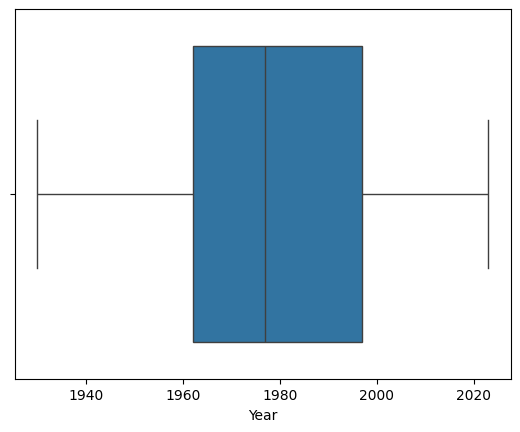

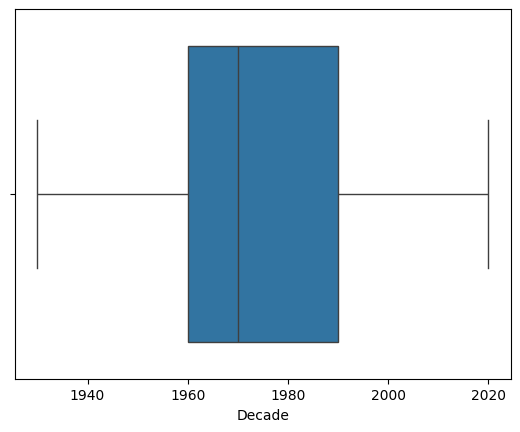

In [16]:
import seaborn as sns

for col in numerics_col:
  sns.boxplot(x=df[col])
  plt.show()